In [29]:
import os, copy, h5py
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import numpy as np
import pandas as pd
from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, temp_dir
from compas_python_utils.cosmic_integration.ClassCOMPAS import COMPASData
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023, madau_dickinson_sfr
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022, compas_log_skew_normal_distribution_metallicity_distribution
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.cosmology_utils import lookback_time_to_redshift
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict
import matplotlib.pyplot as plt
from population_vis import get_formation_efficiency
import time
import warnings
import scipy
from scipy import stats
from get_ZdepSFRD import skew_metallicity_distribution
import pickle
import importlib
import seaborn as sns

In [30]:
filepath = '/Volumes/Elements/Boesky_alpha0.1beta0.5.h5'
fdata = h5py.File(filepath)
all_dco_seeds = fdata['BSE_Double_Compact_Objects']['SEED'][()]
all_seeds = fdata['BSE_System_Parameters']['SEED'][()]
metallicities = fdata["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]
# potentially mask with/without a stable mass transfer or without an envelope
mixture_weight = fdata["BSE_System_Parameters"]["mixture_weight"][()]
TYPES = 'BHNS'
# rates_key = f'Rates_mu00.025_muz-0.052_alpha-1.88_sigma01.15_sigmaz0.0477_{TYPES}_0.1_10.0'
rates_key = f'Rates_{TYPES}_mixed'
# dcomask = fdata[rates_key]['DCOmask']
compasdata = COMPASData(
        path=filepath
    )
compasdata.setCOMPASDCOmask(types=TYPES, withinHubbleTime=True, pessimistic=True)
compasdata.setCOMPASData()

dco_query = np.isin(all_seeds, all_dco_seeds[compasdata.DCOmask])
dco_metallicities = metallicities[dco_query]
dco_mixture_weights = mixture_weight[dco_query]
dco_m1s = fdata['BSE_System_Parameters']['Mass@ZAMS(1)'][dco_query]

# assert len(dco_metallicities) == np.sum(dcomask), "DCO masking failure"

ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid


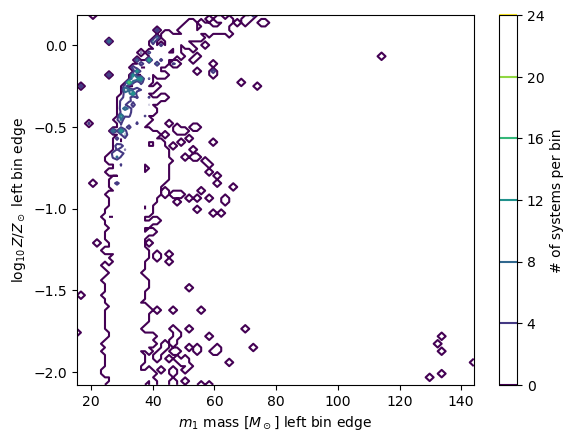

In [31]:
# fig, ax = plt.subplots(1, 1)
# ax.hist2d(dco_m1s, np.log10(dco_metallicities/0.012), weights=dco_mixture_weights, bins=100)
# fig.show()

with open(f'./intrinsic_plotting_data_{TYPES}.pkl', 'rb') as p:
    intrinsic = pickle.load(p)
    # print(intrinsic['all_weights'].shape)
    # print(len(dco_m1s))
    fci_weights = np.sum(intrinsic['all_weights'], axis=1)
    all_snr_weights = np.load('./BNS_LVK_O5_8.npy')
    snr_weights = np.sum(all_snr_weights, axis=0)

    histo, xedges, yedges = np.histogram2d(
        dco_m1s,
        np.log10(dco_metallicities/0.012),
        weights=dco_mixture_weights*fci_weights,#*snr_weights,
        bins=100
    )
    xmesh, ymesh = np.meshgrid(xedges[:-1], yedges[:-1])
    cfig, cax = plt.subplots(1, 1)
    chash = cax.contour(
        xmesh,
        ymesh,
        histo.T,
        levels=5
    )

    colorbar = cfig.colorbar(chash, ax=cax)
    colorbar.set_label('# of systems per bin')

    cax.set_xlabel(r'$m_1$ mass $[M_\odot]$ left bin edge')
    cax.set_ylabel(r'$\log_{10}Z/Z_\odot$ left bin edge')

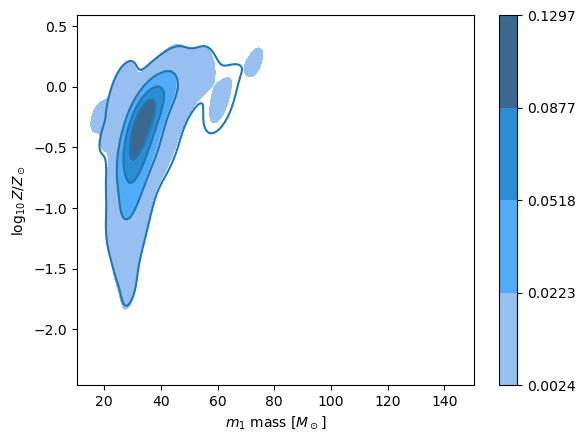

In [50]:
with open(f'./intrinsic_plotting_data_{TYPES}.pkl', 'rb') as p:
    intrinsic = pickle.load(p)
    # print(intrinsic['all_weights'].shape)
    # print(len(dco_m1s))
    fci_weights = np.sum(intrinsic['all_weights'], axis=1)
    def get_snr_weights(fname):
        all_snr_weights = np.load(fname)
        return np.sum(all_snr_weights, axis=0)

    df = pd.DataFrame({
        'm1': dco_m1s,
        'Zs': np.log10(dco_metallicities/0.012)
    })
    # fig, ax = plt.subplots(1, 1)
    plt.figure()
    # cb = cfig.colorbar(chash, ax=cax)
    import matplotlib.colors as mcolors
    sax = sns.kdeplot(df, x='m1', y='Zs',
                weights=dco_mixture_weights*fci_weights,
                fill=True, cbar=True, common_norm=True, levels=5) #, hue='intrinsic', legend=True)
    sax.set_xlabel(r'$m_1$ mass $[M_\odot]$')
    sax.set_ylabel(r'$\log_{10}Z/Z_\odot$')
    
    # sns.kdeplot(df, x='m1', y='Zs',
    #             weights=dco_mixture_weights*fci_weights*get_snr_weights(f'./{TYPES}_CE_8.npy'),
                
    #             levels=5,
    #             cbar_ax=sax,
    #             # cbar_kws={'norm': mcolors.Normalize(vmin=0, vmax=1)},
    #             )
    # sns.kdeplot(df, x='m1', y='Zs',
    #             weights=dco_mixture_weights*fci_weights*get_snr_weights(f'./{TYPES}_LV_O4a_8.npy'),
    #             levels=5,
    #             cbar_ax=sax,
    #             )
    sns.kdeplot(df, x='m1', y='Zs',
                weights=dco_mixture_weights*fci_weights*get_snr_weights(f'./{TYPES}_LVK_O5_8.npy'),
                levels=5,cbar_ax=sax,
                )
    # plt.legend()
    # fig.show()